# OceanTACO Dataset & Query API

A hands-on tour of how OceanTACO structures multi-source ocean data for ML pipelines.

Ocean ML presents a challenge that differs from standard image datasets: data comes from
multiple sensors operating at different resolutions, with different spatial coverage and
sparsity patterns. OceanTACO addresses this with a **query-indexed PyTorch Dataset**: you
describe *where and when* you want data as a `Query` object, and the library handles tile
fetching, spatial cropping, and grid normalization automatically.

This notebook explains the full pipeline step by step:

1. **Query API** — what a `Query` is and how `PatchSize` works
2. **Training queries** — random ocean-biased sampling with `QueryGenerator`
3. **Evaluation queries** — deterministic spatial grid for held-out evaluation
4. **From bbox to pixels** — how geographic window size determines tensor shape, and how `default_patch_size` normalizes it
5. **Dataset instantiation** — pre-indexing at init, `__getitem__` I/O
6. **Sample inspection** — navigating the output dictionary, visualizing all variables
7. **DataLoader & batching** — `collate_ocean_samples`, batch shapes
8. **Query persistence** — saving and reloading query sets for reproducibility

**Prerequisites:** familiarity with PyTorch `Dataset` / `DataLoader`. No prior oceanography knowledge required.

## 1. Installation

In [1]:
# Verify ocean_taco is installed.
# Uncomment one line to install inside this notebook:
%pip install "ocean_taco[hf] @ git+https://github.com/nilsleh/oceanTACO.git@main"
# %pip install ocean-taco[hf]
import ocean_taco
print(f"ocean_taco {ocean_taco.__version__} ready")

  Cloning https://github.com/nilsleh/oceanTACO.git (to revision main) to /tmp/pip-install-jezhfc8_/ocean-taco_eeaa398fea8a4f5db5df9f10cddccaad
  Running command git clone --filter=blob:none --quiet https://github.com/nilsleh/oceanTACO.git /tmp/pip-install-jezhfc8_/ocean-taco_eeaa398fea8a4f5db5df9f10cddccaad
  Resolved https://github.com/nilsleh/oceanTACO.git to commit 0ef0983b4a9735c2229bd34f90f847c4c303bd34
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 80.

## 2. Imports

In [2]:
import os
import warnings
from pathlib import Path

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from ocean_taco.dataset import (
    OceanTACODataset,
    PatchSize,
    Query,
    QueryGenerator,
    collate_ocean_samples,
)
from ocean_taco.dataset.retrieve import HF_DEFAULT_URL

warnings.filterwarnings("ignore", category=RuntimeWarning)


def _configure_cartopy_dir(path: str):
    p = Path(path).expanduser()
    p.mkdir(parents=True, exist_ok=True)
    os.environ["CARTOPY_USER_DIR"] = str(p)
    cartopy.config["data_dir"] = str(p)


_configure_cartopy_dir("./.cartopy")

## 3. Configuration

In [3]:
# -- Configuration --
HF_URL    = HF_DEFAULT_URL
CACHE_DIR = None   # set to a local path string to cache downloaded tiles
OUTPUT    = None   # set to a file path prefix to save figures, e.g. "./figures/ml_dataset"

# Study region: North Atlantic / Gulf Stream area.
# (lon_min, lon_max, lat_min, lat_max)
STUDY_BBOX = (-80, -10, 10, 55)

# Date ranges
TRAIN_DATE_RANGE = ("2023-04-01", "2023-06-30")  # 3-month training window
EVAL_DATE_RANGE  = ("2023-07-01", "2023-08-30")  # 1-month eval window (demo speed)

# Patch and model-facing image size
PATCH_SIZE = PatchSize(10, "deg")  # 10 deg x 10 deg geographic window per sample
IMAGE_SIZE = 64  # fixed model interface for most channels

# Variable-specific output patch sizes (H, W) in pixels.
# These are passed via OceanTACODataset(..., patch_sizes=PATCH_SIZES) and override IMAGE_SIZE.
# We intentionally keep higher detail for L3 SSH products.
PATCH_SIZES = {
    "l3_ssh": (96, 96),
    "l3_swot": (128, 128),
}

# Native resolutions (deg/pixel) for resolution diagnostics in this tutorial.
NATIVE_RES_DEG = {
    "l4_sst": 0.25,
    "l4_sss": 0.25,
    "l3_ssh": 0.25,
    "l4_ssh": 0.25,
    "l3_swot": 0.008,  # approximate along-track spacing for didactic comparison
}

# Convert patch size to degrees; for km patches, use center latitude of study area.
if PATCH_SIZE.unit == "deg":
    patch_lon_deg, patch_lat_deg = PATCH_SIZE.value, PATCH_SIZE.value
else:
    center_lat = 0.5 * (STUDY_BBOX[2] + STUDY_BBOX[3])
    patch_lon_deg, patch_lat_deg = PATCH_SIZE.to_degrees(center_lat=center_lat)

print(
    f"Model-default output size: {IMAGE_SIZE}x{IMAGE_SIZE} px; "
    f"patch footprint ~({patch_lon_deg:.2f}deg x {patch_lat_deg:.2f}deg)"
)
print(f"Per-variable overrides: {PATCH_SIZES}")

# Variables
INPUT_VARS  = ["l4_sst", "l4_sss", "l3_swot", "l3_ssh"]
TARGET_VARS = ["l4_ssh"]

Model-default output size: 64x64 px; patch footprint ~(10.00deg x 10.00deg)
Per-variable overrides: {'l3_ssh': (96, 96), 'l3_swot': (128, 128)}


## 4. Section 1 — What is a `Query`?

A `Query` is a plain Python dataclass with six fields that describe a single training or
evaluation sample:

| Field | Type | Meaning |
|-------|------|---------|
| `lon_min`, `lon_max` | float | Longitude extent of the patch |
| `lat_min`, `lat_max` | float | Latitude extent of the patch |
| `time_start`, `time_end` | str | Date/time window to load data from |

The `.bbox` property returns `(lon_min, lon_max, lat_min, lat_max)` as a tuple —
the convention used throughout the OceanTACO API.

**Key design principle:** a `Query` is a pure data specification. It contains no file
handles, no open connections, and no loaded arrays. This makes queries serializable,
reproducible, and safe to pass across DataLoader worker processes.

### `PatchSize` and latitude distortion

A `PatchSize` object lets you specify patch size in degrees or kilometers. When using
kilometers, it automatically corrects for latitude distortion: longitude degrees shrink
toward the poles (`cos(latitude)` factor), while latitude degrees are roughly constant
at ~111 km/degree.

In [4]:
# Construct a query manually to see its fields
manual_query = Query(
    lon_min=-70, lon_max=-60,
    lat_min=35,  lat_max=45,
    time_start="2023-04-15",
    time_end="2023-04-15",
)
print(f"bbox property : {manual_query.bbox}")
print(f"dict form     : {manual_query.to_dict()}")

# PatchSize: km → degrees, with latitude correction
print("\nPatchSize latitude distortion demo:")
for lat in [0, 30, 45, 60]:
    ps = PatchSize(500, "km")
    lon_deg, lat_deg = ps.to_degrees(center_lat=lat)
    print(f"  500 km at lat={lat:2d}° → lon_deg={lon_deg:.2f}°,  lat_deg={lat_deg:.2f}°")

print(f"\nOur PATCH_SIZE ({PATCH_SIZE}) in degrees: {PATCH_SIZE.to_degrees()}")

bbox property : (-70, -60, 35, 45)
dict form     : {'lon_min': -70, 'lon_max': -60, 'lat_min': 35, 'lat_max': 45, 'time_start': '2023-04-15', 'time_end': '2023-04-15'}

PatchSize latitude distortion demo:
  500 km at lat= 0° → lon_deg=4.50°,  lat_deg=4.50°
  500 km at lat=30° → lon_deg=5.20°,  lat_deg=4.50°
  500 km at lat=45° → lon_deg=6.37°,  lat_deg=4.50°
  500 km at lat=60° → lon_deg=9.01°,  lat_deg=4.50°

Our PATCH_SIZE (10deg) in degrees: (10, 10)


## 5. Section 2 — Generating Training Queries

`QueryGenerator.generate_training_queries` samples random spatial patches and temporal
windows, with three key design choices:

**Ocean bias via land mask.** When a `land_mask_path` is provided, the generator uses a
pre-computed 0.25° global land mask (based on Natural Earth geometries) to reject patches
with more than `max_land_fraction` land coverage. This ensures training samples are
predominantly over open ocean. Without a mask path (as used here for demo speed), all
candidate patches within `bbox_constraint` are accepted.

**Temporal sampling.** Each query's start date is drawn uniformly at random from
`date_range`. The query time window spans `time_window_days` days from the start date,
allowing you to load e.g. a single-day snapshot (`time_window_days=1`) or a multi-day
composite.

**Overlap control.** The `max_spatial_overlap` parameter (IoU threshold, default 1.0 =
disabled) can be used to prevent near-duplicate spatial patches from dominating the
training distribution. Setting it to e.g. 0.3 rejects any candidate patch that overlaps
more than 30% with an already-accepted patch.

In [5]:
qg = QueryGenerator()  # no land_mask_path → skips land filtering (fast demo)

train_queries = qg.generate_training_queries(
    n_queries=100,
    patch_size=PATCH_SIZE,
    date_range=TRAIN_DATE_RANGE,
    bbox_constraint=STUDY_BBOX,
    time_window_days=1,
    max_land_fraction=0.3,
    seed=42,
)

q = train_queries[0]
print(f"Generated {len(train_queries)} training queries")
print(f"\nFirst query:")
print(f"  bbox:        {q.bbox}")
print(f"  time_start:  {q.time_start}")
print(f"  time_end:    {q.time_end}")
print(f"  patch size:  lon={q.lon_max - q.lon_min:.1f}°  lat={q.lat_max - q.lat_min:.1f}°")

Generating 100 training queries...
Generated 100 queries from 100 candidates
Generated 100 training queries

First query:
  bbox:        (-30.581661323117572, -20.581661323117572, 39.82802218501835, 49.82802218501835)
  time_start:  2023-04-02
  time_end:    2023-04-02
  patch size:  lon=10.0°  lat=10.0°


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


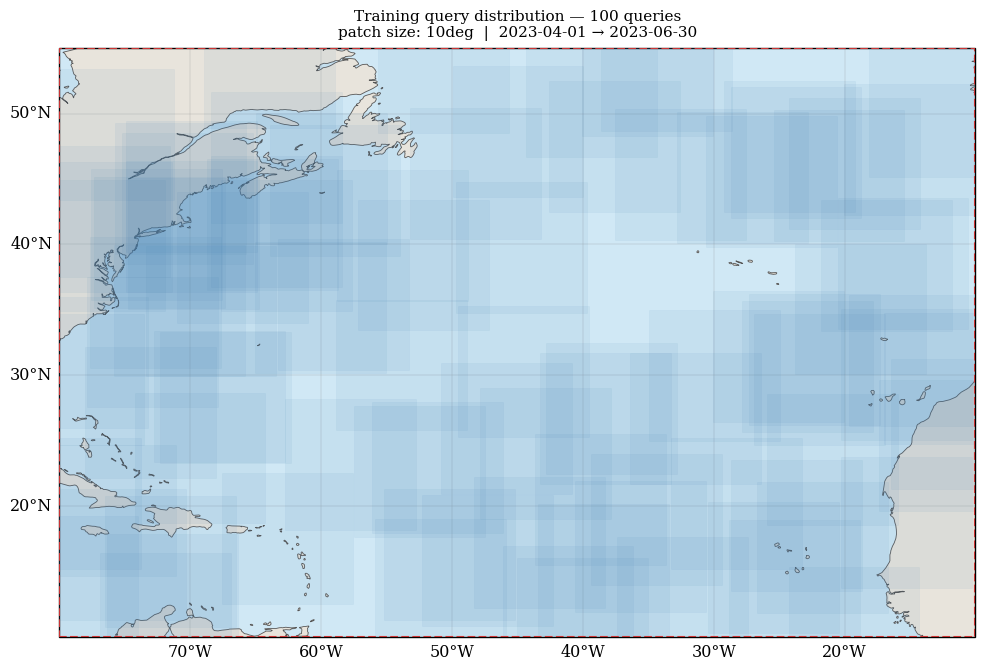

In [6]:
# Figure 1: Spatial distribution of training queries
sns.set_context("paper", font_scale=1.2)
plt.rcParams["font.family"] = "serif"

fig, ax = plt.subplots(
    1, 1, figsize=(10, 7),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

lon_min, lon_max, lat_min, lat_max = STUDY_BBOX
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor="#d0e8f5", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#e8e4dc", edgecolor="none", zorder=1)
ax.coastlines(linewidth=0.6, color="#555", zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, color="gray", zorder=0)
gl.top_labels = False
gl.right_labels = False

# Draw each query bbox as a semi-transparent rectangle.
# Where many queries overlap, the rectangles stack to a darker blue —
# giving a natural 2D density map with no extra computation.
for q in train_queries:
    w = q.lon_max - q.lon_min
    h = q.lat_max - q.lat_min
    rect = mpatches.Rectangle(
        (q.lon_min, q.lat_min), w, h,
        linewidth=0.4, edgecolor="steelblue",
        facecolor="steelblue", alpha=0.08,
        transform=ccrs.PlateCarree(), zorder=3,
    )
    ax.add_patch(rect)

# Outline the study region
study_rect = mpatches.Rectangle(
    (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
    linewidth=1.5, edgecolor="#cc3333", facecolor="none",
    transform=ccrs.PlateCarree(), zorder=4, linestyle="--",
)
ax.add_patch(study_rect)

ax.set_title(
    f"Training query distribution — {len(train_queries)} queries\n"
    f"patch size: {PATCH_SIZE}  |  "
    f"{TRAIN_DATE_RANGE[0]} → {TRAIN_DATE_RANGE[1]}",
    fontsize=11, pad=8,
)
plt.tight_layout()

if OUTPUT:
    plt.savefig(f"{OUTPUT}_train_queries.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Section 3 — Evaluation Queries: Systematic Grid

`generate_eval_queries` builds a **deterministic** grid rather than random samples.
It tiles the entire `bbox` with non-overlapping (or partially overlapping) patches,
then sweeps across dates at a fixed `temporal_stride_days` interval.

- `spatial_overlap=0.0` → non-overlapping tiles (good for independent evaluation)
- `spatial_overlap=0.5` → tiles share half their width/height with neighbors
  (good for sliding-window inference where you need predictions at every point)
- Eval queries are always returned **sorted chronologically**, which makes it easy
  to stream them in time order during evaluation.

The key distinction from training queries:

| | Training | Evaluation |
|--|----------|------------|
| Spatial placement | Random | Deterministic grid |
| Temporal placement | Random within date_range | Fixed stride |
| Reproducibility | Via `seed` | Fully deterministic |
| Typical use | Training loop | Metrics, held-out evaluation |

In [7]:
eval_queries = qg.generate_eval_queries(
    bbox=STUDY_BBOX,
    patch_size=PATCH_SIZE,
    date_range=EVAL_DATE_RANGE,
    spatial_overlap=0.0,
    temporal_stride_days=7,   # one query set per week
    time_window_days=1,
)

print(f"Training queries : {len(train_queries):4d}  (random,    {TRAIN_DATE_RANGE[0]} → {TRAIN_DATE_RANGE[1]})")
print(f"Eval queries     : {len(eval_queries):4d}  (grid,      {EVAL_DATE_RANGE[0]} → {EVAL_DATE_RANGE[1]}, 7-day stride)")
print(f"\nFirst eval query: {eval_queries[0].to_dict()}")
print(f"Last  eval query: {eval_queries[-1].to_dict()}")

Generating eval grid: 7x5x9 = 315 candidates
Generated 315 valid eval queries
Training queries :  100  (random,    2023-04-01 → 2023-06-30)
Eval queries     :  315  (grid,      2023-07-01 → 2023-08-30, 7-day stride)

First eval query: {'lon_min': -80.0, 'lon_max': -70.0, 'lat_min': 10.0, 'lat_max': 20.0, 'time_start': '2023-07-01', 'time_end': '2023-07-01'}
Last  eval query: {'lon_min': -20.0, 'lon_max': -10.0, 'lat_min': 45.0, 'lat_max': 55.0, 'time_start': '2023-08-26', 'time_end': '2023-08-26'}


### Visual intuition: random vs grid queries

The two query modes have distinct spatial patterns:

- Training queries are **randomly placed**, so patches overlap irregularly and coverage density is uneven.
- Evaluation queries are **systematic**, forming a regular lattice that covers the study region uniformly.

In the figure below:
- Left panel shows training queries (random overlap pattern).
- Right panel shows evaluation queries (structured grid pattern).

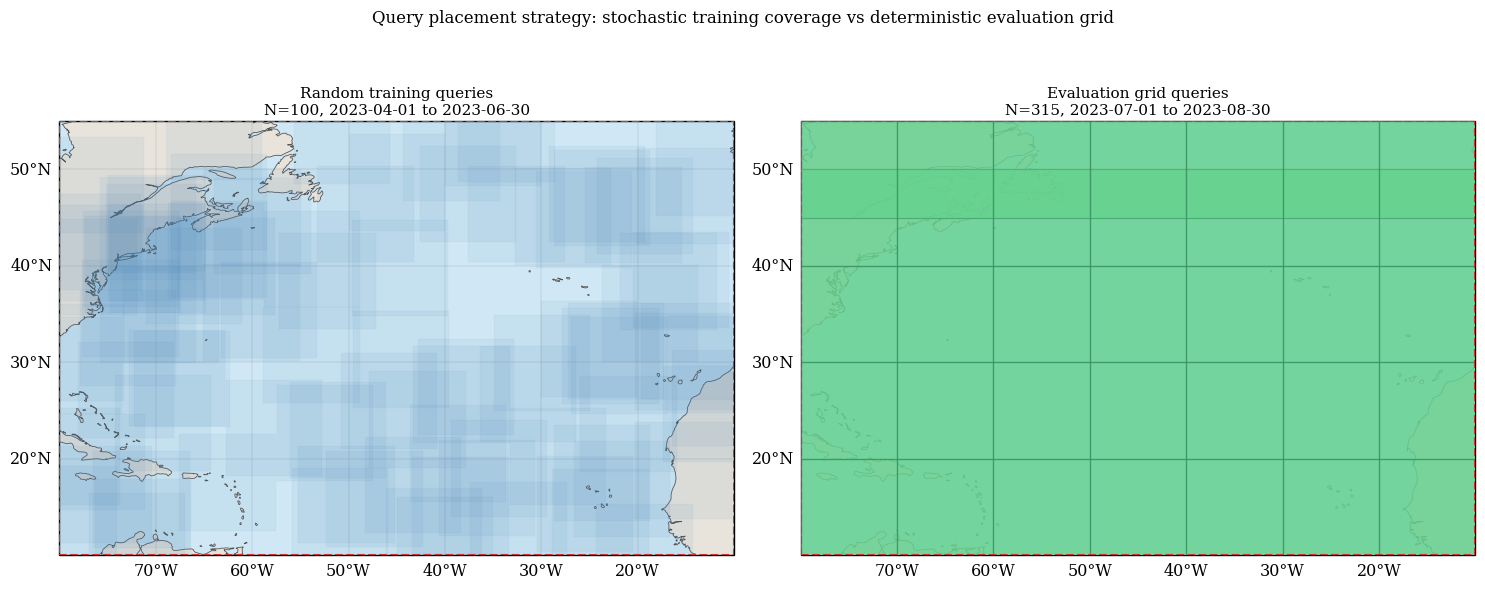

In [8]:
# Figure 2: Compare random training queries vs systematic eval queries
sns.set_context("paper", font_scale=1.2)
plt.rcParams["font.family"] = "serif"

fig, axes = plt.subplots(
    1, 2, figsize=(15, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

lon_min, lon_max, lat_min, lat_max = STUDY_BBOX

for ax in axes:
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, facecolor="#d0e8f5", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#e8e4dc", edgecolor="none", zorder=1)
    ax.coastlines(linewidth=0.6, color="#555", zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, color="gray", zorder=0)
    gl.top_labels = False
    gl.right_labels = False

# Left: random training queries
for q in train_queries:
    rect = mpatches.Rectangle(
        (q.lon_min, q.lat_min),
        q.lon_max - q.lon_min,
        q.lat_max - q.lat_min,
        linewidth=0.35,
        edgecolor="steelblue",
        facecolor="steelblue",
        alpha=0.08,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )
    axes[0].add_patch(rect)

# Right: deterministic eval grid queries
for q in eval_queries:
    rect = mpatches.Rectangle(
        (q.lon_min, q.lat_min),
        q.lon_max - q.lon_min,
        q.lat_max - q.lat_min,
        linewidth=0.8,
        edgecolor="#2f855a",
        facecolor="#68d391",
        alpha=0.20,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )
    axes[1].add_patch(rect)

# Outline study bbox in both panels
for ax in axes:
    study_rect = mpatches.Rectangle(
        (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
        linewidth=1.5, edgecolor="#cc3333", facecolor="none",
        transform=ccrs.PlateCarree(), zorder=4, linestyle="--",
    )
    ax.add_patch(study_rect)

axes[0].set_title(
    f"Random training queries\nN={len(train_queries)}, {TRAIN_DATE_RANGE[0]} to {TRAIN_DATE_RANGE[1]}",
    fontsize=11,
)
axes[1].set_title(
    f"Evaluation grid queries\nN={len(eval_queries)}, {EVAL_DATE_RANGE[0]} to {EVAL_DATE_RANGE[1]}",
    fontsize=11,
)

fig.suptitle(
    "Query placement strategy: stochastic training coverage vs deterministic evaluation grid",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()

if OUTPUT:
    plt.savefig(f"{OUTPUT}_train_vs_eval_queries.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Section 4 -- From Bbox to Pixels: The Full Resolution Chain

From an ML perspective, there are two competing goals:

1. Keep a stable model interface (fixed channel sizes for batching and architecture simplicity).
2. Preserve as much native spatial information as possible.

In this notebook we use a **model-first default** and then selective per-variable overrides:

- Default: `IMAGE_SIZE = 64` for most channels.
- Overrides via `patch_sizes`: `l3_ssh -> 96x96`, `l3_swot -> 128x128`.

This is exactly what `OceanTACODataset(..., default_patch_size=..., patch_sizes=...)` is for.

### Step 1: Query bbox defines the geographic window

A `PatchSize(10, "deg")` means each query covers a 10 deg x 10 deg patch.
This is the geographic footprint of every sample.

### Step 2: Native source resolution determines raw pixel count

Each data source has a fixed native resolution baked into its NetCDF files:

| Variable | Source | Native res | Approx raw pixels for 10 deg patch |
|----------|--------|------------|-------------------------------------|
| `l4_sst` | L4 gridded | 0.25 deg/px | 40 x 40 |
| `l4_sss` | L4 gridded | 0.25 deg/px | 40 x 40 |
| `l3_ssh` | L3 nadir altimetry | 0.25 deg/px (re-gridded) | 40 x 40 |
| `l4_ssh` | L4 DUACS | 0.25 deg/px | 40 x 40 |
| `l3_swot` | SWOT wide-swath | ~0.008 deg/px along-track | much denser, sparse swath |

SWOT (`l3_swot`) is fundamentally different: it is a sparse along-track swath, not a
regular grid. Only pixels that happen to fall within the bbox on that date are present;
most pixels are NaN (or zero after NaN-filling). This is why SWOT and SSH variables
use a dark background in visualizations.

### Step 3: Dataset resizing policy (default + overrides)

`OceanTACODataset` applies this logic for gridded variables:

- Use `patch_sizes[var]` when provided.
- Otherwise use `default_patch_size`.
- Point sources (e.g., Argo) are not resized.

So in our setup:

- `l4_sst`, `l4_sss`, `l4_ssh` -> `64x64` (default)
- `l3_ssh` -> `96x96` (override)
- `l3_swot` -> `128x128` (override)

### Step 4: What resize does internally

For gridded variables, the dataset calls `_interpolate_to_patch(data, (H, W))`.
This uses bilinear interpolation with NaN-mask normalization, so no-data regions are not
allowed to bleed strongly into valid regions.

### Step 5: Implication for model design

With variable-specific patch sizes, channels no longer have identical spatial shapes.
That is often desirable for fidelity, but requires downstream handling:

- per-variable encoders,
- explicit resampling to a common resolution before fusion, or
- custom multi-resolution fusion blocks.

If you prefer strict same-shape channels everywhere, omit `patch_sizes` and rely only on
`default_patch_size`.

In [9]:
# Resolution summary: native estimate vs requested output size per variable
print(
    f"PATCH_SIZE = {PATCH_SIZE} -> geographic window "
    f"({patch_lon_deg:.2f}deg x {patch_lat_deg:.2f}deg)"
)
print(f"Default output size : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Overrides (patch_sizes): {PATCH_SIZES}")
print()

header = f"{'Variable':<12} {'Native res':>12} {'Native px':>12} {'Requested px':>14} {'Resize ratio':>12}"
print(header)
print("-" * len(header))

for var in INPUT_VARS + TARGET_VARS:
    req_h, req_w = PATCH_SIZES.get(var, (IMAGE_SIZE, IMAGE_SIZE))
    native_res = NATIVE_RES_DEG.get(var)

    if native_res is not None:
        native_h = int(round(patch_lat_deg / native_res))
        native_w = int(round(patch_lon_deg / native_res))
        ratio_h = req_h / max(native_h, 1)
        ratio_w = req_w / max(native_w, 1)
        native_res_str = f"{native_res:.3f}"
        native_px_str = f"{native_h}x{native_w}"
        ratio_str = f"{ratio_h:.2f}x/{ratio_w:.2f}x"
    else:
        native_res_str = "unknown"
        native_px_str = "irregular"
        ratio_str = "n/a"

    print(
        f"{var:<12} {native_res_str:>12} {native_px_str:>12} "
        f"{f'{req_h}x{req_w}':>14} {ratio_str:>12}"
    )

print()
print("Interpretation:")
print("- ratio close to 1.0x means requested size is near native sampling")
print("- >1.0x means upsampling, <1.0x means downsampling")
print("- l3_swot is sparse/irregular, so this ratio is only a rough guide")

PATCH_SIZE = 10deg -> geographic window (10.00deg x 10.00deg)
Default output size : 64x64
Overrides (patch_sizes): {'l3_ssh': (96, 96), 'l3_swot': (128, 128)}

Variable       Native res    Native px   Requested px Resize ratio
------------------------------------------------------------------
l4_sst              0.250        40x40          64x64  1.60x/1.60x
l4_sss              0.250        40x40          64x64  1.60x/1.60x
l3_swot             0.008    1250x1250        128x128  0.10x/0.10x
l3_ssh              0.250        40x40          96x96  2.40x/2.40x
l4_ssh              0.250        40x40          64x64  1.60x/1.60x

Interpretation:
- ratio close to 1.0x means requested size is near native sampling
- >1.0x means upsampling, <1.0x means downsampling
- l3_swot is sparse/irregular, so this ratio is only a rough guide


## 8. Section 5 — Dataset Instantiation

`OceanTACODataset.__init__` runs a **single SQL query** to the TACO catalog that fetches
the file-level index covering all queries across the entire time range, then splits the
results by per-query date range in memory. This one-shot pre-indexing is what makes the
dataset safe for `DataLoader` with `num_workers > 0`: worker processes never touch
`tacoreader` or the catalog; they only use the pre-built file index.

The init step makes **one network request** to the HuggingFace catalog (~5–30 s depending
on network speed). All subsequent `__getitem__` calls do byte-range HTTP reads directly
to individual tile files.

> **Demo note:** We pass `train_queries[:20]` here so the init completes quickly.
> In real training, pass the full query list.

In [10]:
print("Initializing dataset (one network request to HF catalog) ...")
dataset = OceanTACODataset(
    taco_path=HF_URL,
    queries=train_queries[:20],   # slice for demo speed
    input_variables=INPUT_VARS,
    target_variables=TARGET_VARS,
    default_patch_size=(IMAGE_SIZE, IMAGE_SIZE),
    patch_sizes=PATCH_SIZES,
    temporal_agg="mean",
)

print(f"Dataset ready: {len(dataset)} samples")
print(f"Input variables:  {dataset.input_variables}")
print(f"Target variables: {dataset.target_variables}")
print("\nRequested output patch sizes (H, W):")
for var in INPUT_VARS + TARGET_VARS:
    req = PATCH_SIZES.get(var, (IMAGE_SIZE, IMAGE_SIZE))
    tag = "override" if var in PATCH_SIZES else "default"
    print(f"  {var:<12}: {req}  [{tag}]")

Initializing dataset (one network request to HF catalog) ...
Dataset ready: 20 samples
Input variables:  ['l4_sst', 'l4_sss', 'l3_swot', 'l3_ssh']
Target variables: ['l4_ssh']

Requested output patch sizes (H, W):
  l4_sst      : (64, 64)  [default]
  l4_sss      : (64, 64)  [default]
  l3_swot     : (128, 128)  [override]
  l3_ssh      : (96, 96)  [override]
  l4_ssh      : (64, 64)  [default]


## 9. Section 6 — Inspecting a Single Sample

`dataset[i]` returns a nested dictionary with four top-level keys:

```python
sample = {
    "inputs": {
        "l4_sst":  {"data": Tensor(H, W), "lats": Tensor(H), "lons": Tensor(W)},
        "l4_sss":  {"data": Tensor(H, W), "lats": Tensor(H), "lons": Tensor(W)},
        "l3_swot": {"data": Tensor(H, W), "lats": Tensor(H), "lons": Tensor(W)},
        "l3_ssh":  {"data": Tensor(H, W), "lats": Tensor(H), "lons": Tensor(W)},
    },
    "targets": {
        "l4_ssh":  {"data": Tensor(H, W), "lats": Tensor(H), "lons": Tensor(W)},
    },
    "coords": {"lat": Tensor(H), "lon": Tensor(W)},  # from first available variable
    "metadata": {
        "bbox":       (lon_min, lon_max, lat_min, lat_max),
        "time_range": (time_start, time_end),
        "n_files":    int,  # number of tile files loaded for this query
    },
}
```

**Important edge cases:**
- If no data files exist for a variable at the query's bbox/date, the value is `None` instead of a dict.
- `lats`/`lons` are 1D coordinate arrays for the regular grid (after resize: `np.linspace`).
  For point sources like Argo floats, they would be the individual float positions.
- NaN values in the original data are replaced with `0.0` after loading (use the data mask
  from `l3_swot` visualizations to distinguish zero-signal from no-data).

In [11]:
sample = dataset[0]

print("=== Sample metadata ===")
meta = sample["metadata"]
print(f"  bbox       : {meta['bbox']}")
print(f"  time_range : {meta['time_range']}")
print(f"  n_files    : {meta['n_files']}")

print("\n=== Input tensor shapes (actual vs requested) ===")
for var, val in sample["inputs"].items():
    req_shape = PATCH_SIZES.get(var, (IMAGE_SIZE, IMAGE_SIZE))
    if val is not None:
        data_shape = tuple(val["data"].shape)
        lats_shape = tuple(val["lats"].shape) if val["lats"] is not None else None
        lons_shape = tuple(val["lons"].shape) if val["lons"] is not None else None
        print(
            f"  {var:<12}: data={data_shape}  requested={req_shape}  "
            f"lats={lats_shape}  lons={lons_shape}"
        )
    else:
        print(f"  {var:<12}: None  (no data for this query)  requested={req_shape}")

print("\n=== Target tensor shapes (actual vs requested) ===")
for var, val in sample["targets"].items():
    req_shape = PATCH_SIZES.get(var, (IMAGE_SIZE, IMAGE_SIZE))
    if val is not None:
        print(f"  {var:<12}: data={tuple(val['data'].shape)}  requested={req_shape}")
    else:
        print(f"  {var:<12}: None  requested={req_shape}")

print("\n=== Shared coords ===")
print(f"  lat: {tuple(sample['coords']['lat'].shape)}  "
      f"range [{sample['coords']['lat'][0]:.2f}°, {sample['coords']['lat'][-1]:.2f}°]")
print(f"  lon: {tuple(sample['coords']['lon'].shape)}  "
      f"range [{sample['coords']['lon'][0]:.2f}°, {sample['coords']['lon'][-1]:.2f}°]")

=== Sample metadata ===
  bbox       : (-30.581661323117572, -20.581661323117572, 39.82802218501835, 49.82802218501835)
  time_range : ('2023-04-02', '2023-04-02')
  n_files    : 40

=== Input tensor shapes (actual vs requested) ===
  l4_sst      : data=(64, 64)  requested=(64, 64)  lats=(64,)  lons=(64,)
  l4_sss      : data=(64, 64)  requested=(64, 64)  lats=(64,)  lons=(64,)
  l3_swot     : data=(128, 128)  requested=(128, 128)  lats=(128,)  lons=(128,)
  l3_ssh      : data=(96, 96)  requested=(96, 96)  lats=(96,)  lons=(96,)

=== Target tensor shapes (actual vs requested) ===
  l4_ssh      : data=(64, 64)  requested=(64, 64)

=== Shared coords ===
  lat: (64,)  range [39.83°, 49.83°]
  lon: (64,)  range [-30.58°, -20.58°]


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


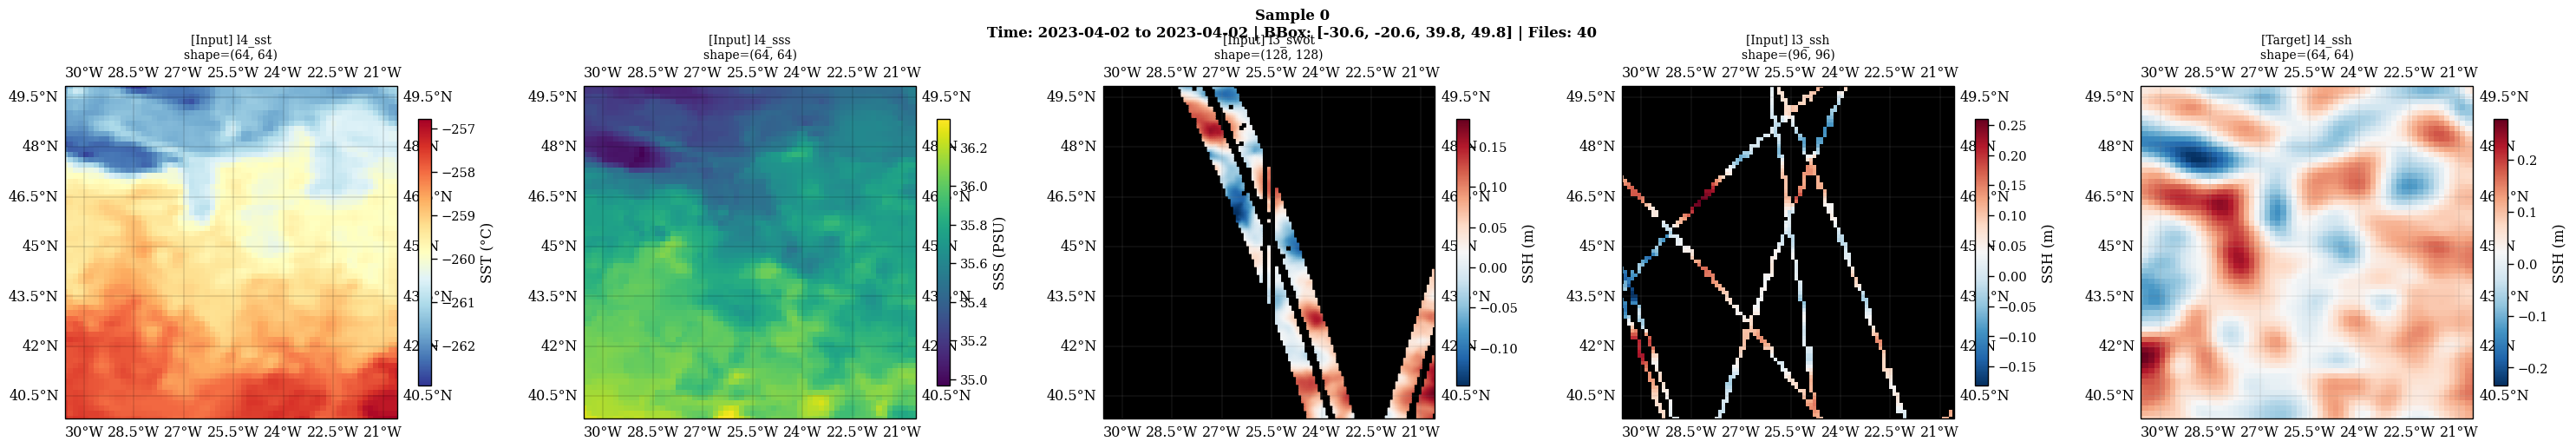

In [12]:
# Figure 3: Visualize all variables in this sample using the built-in method.
# It handles: cartopy projection, per-variable colormaps, dark bg for SSH/SWOT,
# NaN masking for sparse L3 data, and a descriptive suptitle.
dataset.visualize_sample(
    sample,
    title="Sample 0",
    max_cols=5,
    save_path=f"{OUTPUT}_sample0.png" if OUTPUT else None,
)

## 10. Section 7 -- DataLoader and Batching

`collate_ocean_samples` is the custom collate function required by `DataLoader`. It does
two things:

1. **Handles `None` values.** If a variable is missing for some samples in the batch,
   those samples are **silently dropped** from that variable's tensor. This means a
   variable with `k < B` valid samples produces a tensor of shape `(k, H, W)` -- not `(B, H, W)`.
   Downstream code should account for this.

2. **Zero-pads to max shape.** If variables or samples have different spatial sizes,
   tensors are zero-padded to the largest spatial shape in that variable's batch slice
   before stacking.

This padding behavior is especially relevant when using `patch_sizes` overrides
(as in this notebook), because different variables intentionally have different
requested spatial resolutions (`64x64`, `96x96`, `128x128`).

The resulting batch tensors still have per-variable shape `(k, H_var, W_var)` where
`k <= B` and `(H_var, W_var)` can differ by variable.

> **`num_workers` guidance:** Use `num_workers=0` for notebooks (no subprocess overhead).
> For training, `num_workers >= 2` is safe and recommended -- the pre-built file index
> means workers never access the TACO catalog.

In [13]:
loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_ocean_samples,
)

batch = next(iter(loader))
B = len(batch["metadata"]["bboxes"])

print(f"Requested batch size: {B}\n")
print("Top-level batch keys:", list(batch.keys()))

print("\nInput tensor shapes (k, H, W):")
for var, tensor in batch["inputs"].items():
    req = PATCH_SIZES.get(var, (IMAGE_SIZE, IMAGE_SIZE))
    if tensor is not None:
        k = tensor.shape[0]
        missing = B - k
        note = f"  <- {missing} sample(s) missing" if missing > 0 else ""
        print(f"  {var:<12}: {tuple(tensor.shape)}  requested={req}{note}")
    else:
        print(f"  {var:<12}: None  requested={req}  (no data for any sample)")

print("\nTarget tensor shapes (k, H, W):")
for var, tensor in batch["targets"].items():
    req = PATCH_SIZES.get(var, (IMAGE_SIZE, IMAGE_SIZE))
    shape = tuple(tensor.shape) if tensor is not None else "None"
    print(f"  {var:<12}: {shape}  requested={req}")

print("\nMetadata summary:")
print(f"  n_bboxes: {len(batch['metadata']['bboxes'])}")
print(f"  n_time_ranges: {len(batch['metadata']['time_ranges'])}")

print("\nSample bboxes in this batch:")
for i, (bbox, tr) in enumerate(
    zip(batch["metadata"]["bboxes"], batch["metadata"]["time_ranges"])
):
    print(f"  [{i}] bbox={bbox}  time={tr}")

Requested batch size: 4

Top-level batch keys: ['inputs', 'targets', 'coords', 'metadata']

Input tensor shapes (k, H, W):
  l4_sst      : (4, 64, 64)  requested=(64, 64)
  l4_sss      : (4, 64, 64)  requested=(64, 64)
  l3_swot     : (4, 128, 128)  requested=(128, 128)
  l3_ssh      : (4, 96, 96)  requested=(96, 96)

Target tensor shapes (k, H, W):
  l4_ssh      : (4, 64, 64)  requested=(64, 64)

Metadata summary:
  n_bboxes: 4
  n_time_ranges: 4

Sample bboxes in this batch:
  [0] bbox=(-20.07062142954446, -10.07062142954446, 42.243402739666195, 52.243402739666195)  time=('2023-05-31', '2023-05-31')
  [1] bbox=(-34.921500926893884, -24.921500926893884, 24.9536389472299, 34.953638947229905)  time=('2023-06-10', '2023-06-10')
  [2] bbox=(-33.27111972591208, -23.27111972591208, 15.22574248031496, 25.22574248031496)  time=('2023-06-16', '2023-06-16')
  [3] bbox=(-30.581661323117572, -20.581661323117572, 39.82802218501835, 49.82802218501835)  time=('2023-04-02', '2023-04-02')


## 11. Section 8 — Query Persistence

Persisting your query sets is essential for reproducible experiments. The same random
seed produces the same queries within a single Python session, but not necessarily across
library versions or NumPy updates. Saving queries to disk guarantees that you can reload
the exact same training/evaluation split months later.

`QueryGenerator.save_queries` writes:
- `<path>.parquet` — the query table (bbox + time fields)
- `<path>.json` — optional metadata sidecar (any dict you want to attach)

In [14]:
QUERY_SAVE_PATH = Path("./train_queries_north_atlantic")

# Save
QueryGenerator.save_queries(
    train_queries,
    QUERY_SAVE_PATH,
    metadata={
        "region":      "North Atlantic",
        "bbox":        list(STUDY_BBOX),
        "patch_size":  str(PATCH_SIZE),
        "date_range":  list(TRAIN_DATE_RANGE),
        "n_queries":   len(train_queries),
    },
)
print(f"Saved {len(train_queries)} queries to {QUERY_SAVE_PATH}.parquet + .json")

# Reload
reloaded_queries, meta = QueryGenerator.load_queries(QUERY_SAVE_PATH)
print(f"Reloaded {len(reloaded_queries)} queries")
print(f"Metadata: {meta}")

# Verify round-trip
match = all(
    r.to_dict() == o.to_dict()
    for r, o in zip(reloaded_queries, train_queries)
)
print(f"\nAll queries match original: {match}")

Saved 100 queries to train_queries_north_atlantic
Saved 100 queries to train_queries_north_atlantic.parquet + .json
Reloaded 100 queries
Metadata: {'n_queries': 100, 'generated_at': '2026-03-27T00:10:24.569161', 'region': 'North Atlantic', 'bbox': [-80, -10, 10, 55], 'patch_size': '10deg', 'date_range': ['2023-04-01', '2023-06-30']}

All queries match original: True


## Summary

| Component | Purpose | Key parameter |
|-----------|---------|---------------|
| `Query` | Spatial-temporal sample specification | `bbox`, `time_start`, `time_end` |
| `PatchSize` | Geographic window size with lat correction | `value`, `unit` (`"deg"` or `"km"`) |
| `QueryGenerator` | Produces training (random) and eval (grid) queries | `land_mask_path`, `max_land_fraction` |
| `OceanTACODataset` | Pre-indexed PyTorch Dataset | `default_patch_size`, `temporal_agg` |
| `collate_ocean_samples` | DataLoader collate fn | handles `None` + zero-padding |


## Further Reading

> For a deeper intuition on how query-generation parameters affect spatial coverage and temporal cadence, see:
[Spatio-Temporal Query Generation Intuition](spatio_temporal_query_generation.ipynb)